In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph , START , END
from langchain_huggingface import  ChatHuggingFace,HuggingFaceEndpoint

In [2]:
import dotenv
dotenv.load_dotenv()
import os

In [3]:
HUGGINGFACEHUB_API_TOKEN = os.getenv('HUGGINGFACEHUB_API_TOKEN')

In [4]:
llm = HuggingFaceEndpoint(
    repo_id='meta-llama/Llama-3.1-8B-Instruct',
    task='text-generation',
    huggingfacehub_api_token= HUGGINGFACEHUB_API_TOKEN
)

d:\workspace\LangGraph learning\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
model = ChatHuggingFace(llm = llm)

In [6]:
model.invoke('How hot is sun?').content

"The surface temperature of the sun is approximately 5,500°C (9,932°F). However, the temperature at the core of the sun is estimated to be around 15,000,000°C (27,000,000°F). This extreme heat is due to nuclear reactions that occur within the sun's core, where hydrogen atoms are fused into helium, releasing vast amounts of energy in the process.\n\nTo give you a better idea, here's a breakdown of the sun's temperature at different layers:\n\n* Surface (photosphere): 5,500°C (9,932°F)\n* Chromosphere: 10,000°C (18,032°F)\n* Corona: 1,000,000°C to 2,000,000°C (1,832,000°F to 3,632,000°F)\n* Core: 15,000,000°C (27,000,000°F)"

In [7]:
class LLMState(TypedDict):
    question:str
    answer:str


In [8]:
def llm_ques_ans(state:LLMState)->LLMState:
    
    question = state['question']

    #prompt 
    prompt = f'Answer the following question {question}'

    answer = model.invoke(prompt).content

    state['answer']=answer

    return state


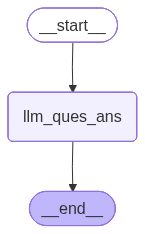

In [9]:
# create graph
graph = StateGraph(LLMState)

# create nodes
graph.add_node('llm_ques_ans',llm_ques_ans)

graph.add_edge(START,'llm_ques_ans')
graph.add_edge('llm_ques_ans',END)

workflow = graph.compile()
workflow

In [10]:
inital_state = {'question':"How hot is sun?"}
final_state = workflow.invoke(inital_state)

print(final_state)

{'question': 'How hot is sun?', 'answer': "The surface temperature of the sun is approximately 5500°C (10,000°F) or 5778 Kelvin (K). However, the core temperature is much hotter, around 15,000,000°C (27,000,000°F) or 15,000,000 Kelvin (K).\n\nThis extreme heat is due to nuclear reactions that occur within the sun's core, where hydrogen atoms are fused together to form helium, releasing vast amounts of energy in the process. This energy is what makes the sun shine and is what keeps our solar system warm.\n\nTo put these temperatures into perspective, the hottest fire on Earth can reach temperatures of around 1800°C (3300°F). The surface of the sun is about 3000 times hotter than that."}


In [11]:
final_state['answer']

"The surface temperature of the sun is approximately 5500°C (10,000°F) or 5778 Kelvin (K). However, the core temperature is much hotter, around 15,000,000°C (27,000,000°F) or 15,000,000 Kelvin (K).\n\nThis extreme heat is due to nuclear reactions that occur within the sun's core, where hydrogen atoms are fused together to form helium, releasing vast amounts of energy in the process. This energy is what makes the sun shine and is what keeps our solar system warm.\n\nTo put these temperatures into perspective, the hottest fire on Earth can reach temperatures of around 1800°C (3300°F). The surface of the sun is about 3000 times hotter than that."